# Instalación de Dependencias

Ejecuta esta celda para instalar todas las librerías necesarias para el análisis (pandas, seaborn, matplotlib, etc.).

In [1]:
%pip install -r ../requirements.txt

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


# Análisis Exploratorio de Datos (EDA) - CBIS-DDSM (Real)

Este análisis utiliza los metadatos reales descargados de CBIS-DDSM.
Objetivos:
- Entender la distribución de las patologías (Benigno vs Maligno).
- Analizar la densidad mamaria y su relación con el diagnóstico.
- Evaluar la correlación entre la valoración BI-RADS (Assessment) y la patología real.
- **Nuevo**: Análisis a nivel de paciente (Patient-Level Analysis).

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os

# Configuración de estilo
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams['figure.figsize'] = (10, 6)

# Añadir src al path para usar módulos compartidos
sys.path.append('..')
from src.data_loader import load_cbis_ddsm_data, get_patient_summary

# Cargar datos reales descargados
datasets = load_cbis_ddsm_data('../data')
if datasets:
    file_name = 'mass_case_description_train_set.csv'
    df = datasets.get(file_name, datasets[list(datasets.keys())[0]])
    print(f"Cargado dataset REAL: {file_name}")
    print(f"Total de registros: {len(df)}")
else:
    print("No se encontraron datos en ../data/")

Cargado dataset REAL: mass_case_description_train_set.csv
Total de registros: 1318


## Visualización Inicial del Dataset
Echemos un vistazo a las primeras filas para entender las columnas disponibles.

In [3]:
if datasets:
    # Mostrar las primeras 5 filas
    display(df.head())
    # Información sobre tipos de datos
    print("\nInformación del Dataset:")
    df.info()

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....



Información del Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1318 entries, 0 to 1317
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   patient_id               1318 non-null   object
 1   breast_density           1318 non-null   int64 
 2   left or right breast     1318 non-null   object
 3   image view               1318 non-null   object
 4   abnormality id           1318 non-null   int64 
 5   abnormality type         1318 non-null   object
 6   mass shape               1314 non-null   object
 7   mass margins             1275 non-null   object
 8   assessment               1318 non-null   int64 
 9   pathology                1318 non-null   object
 10  subtlety                 1318 non-null   int64 
 11  image file path          1318 non-null   object
 12  cropped image file path  1318 non-null   object
 13  ROI mask file path       1318 non-null   object
dtypes: int64(4), o

## Análisis de Datos Faltantes (Nulls)
Es vital identificar qué información nos falta antes de entrenar el modelo.

Columnas con valores nulos:


,Total Nulos,% de Nulos
mass margins,43,3.262519
mass shape,4,0.303490


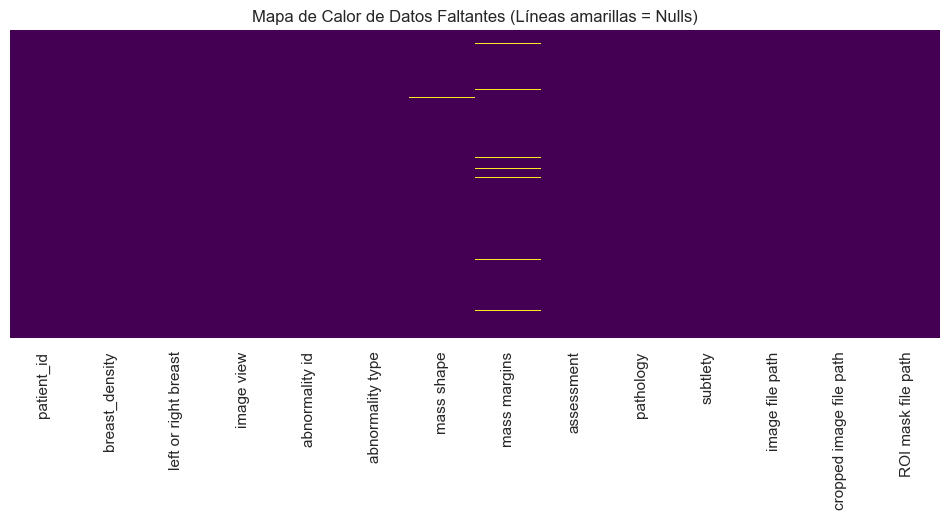

In [4]:
# Cálculo de nulos por columna
nulls = df.isnull().sum()
null_pct = 100 * df.isnull().sum() / len(df)
null_table = pd.concat([nulls, null_pct], axis=1)
null_table.columns = ['Total Nulos', '% de Nulos']
print("Columnas con valores nulos:")
display(null_table[null_table['Total Nulos'] > 0].sort_values('% de Nulos', ascending=False))

# Visualización con heatmap
if df.isnull().values.any():
    plt.figure(figsize=(12, 4))
    sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
    plt.title('Mapa de Calor de Datos Faltantes (Líneas amarillas = Nulls)')
    plt.show()

## 1. Distribución de Patología
Balance de clases global del dataset.

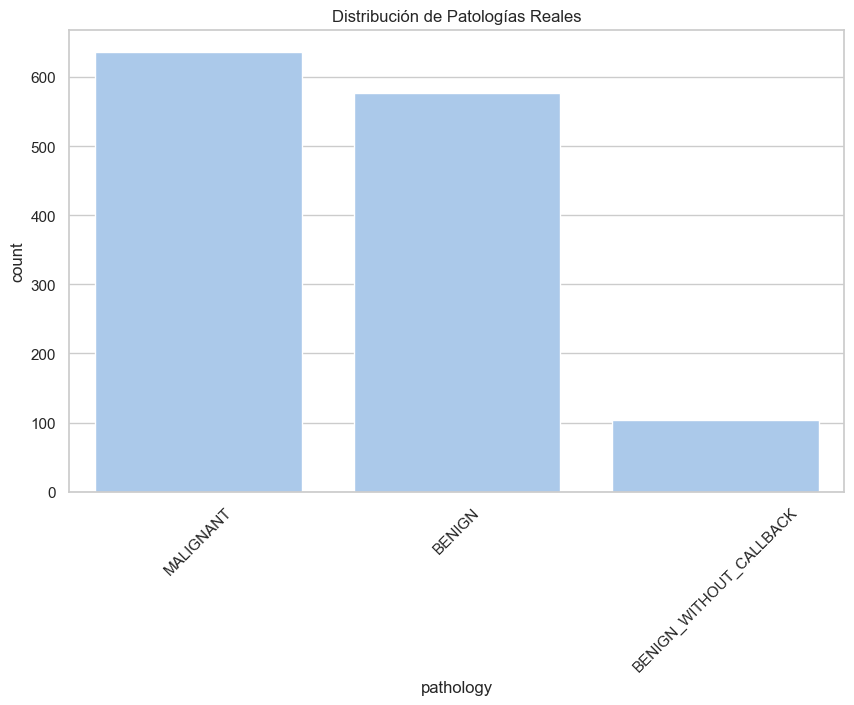

In [5]:
if 'pathology' in df.columns:
    sns.countplot(data=df, x='pathology')
    plt.title('Distribución de Patologías Reales')
    plt.xticks(rotation=45)
    plt.show()

## 2. Análisis a nivel de PACIENTE
Crucial para el rigor metodológico de la tesis. ¿Cuántos pacientes únicos tenemos?

Número total de pacientes únicos: 691


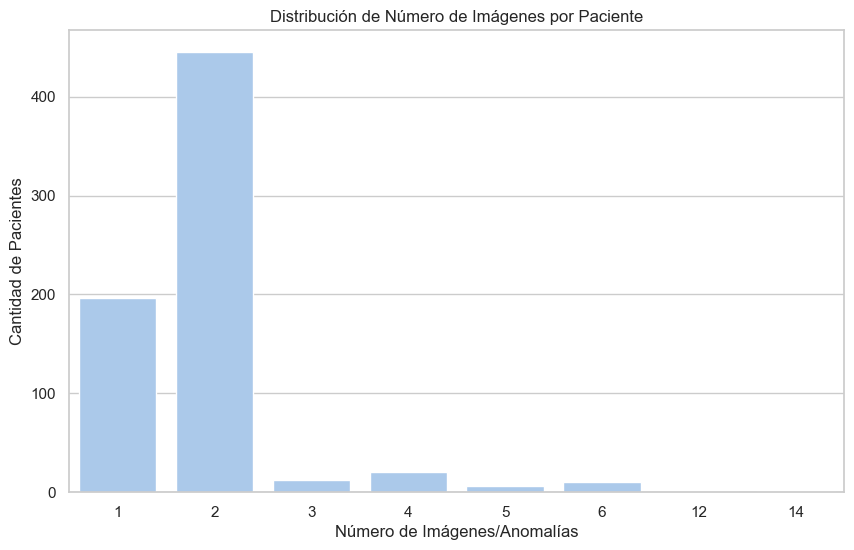

In [6]:
patient_summary = get_patient_summary(df)
if patient_summary is not None:
    print(f"Número total de pacientes únicos: {len(patient_summary)}")
    
    # Distribución de cuántas imágenes hay por paciente
    sns.countplot(data=patient_summary, x='image_count')
    plt.title('Distribución de Número de Imágenes por Paciente')
    plt.xlabel('Número de Imágenes/Anomalías')
    plt.ylabel('Cantidad de Pacientes')
    plt.show()

## 3. Patología por Paciente
¿Cuántos pacientes presentan malignidad vs benignidad?

/var/folders/n9/rzbr2qw904q1hzjdqbsd0p900000gn/T/ipykernel_69198/1585197612.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=patient_summary, x='pathology', palette='magma')


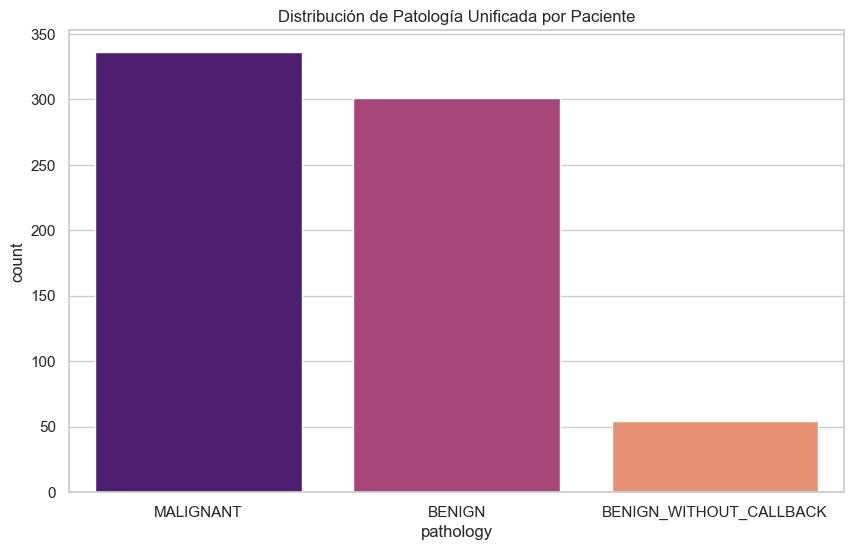

In [7]:
if patient_summary is not None:
    sns.countplot(data=patient_summary, x='pathology', palette='magma')
    plt.title('Distribución de Patología Unificada por Paciente')
    plt.show()

## 4. BI-RADS Assessment y Malignidad
Relación entre la valoración del radiólogo y la patología real.

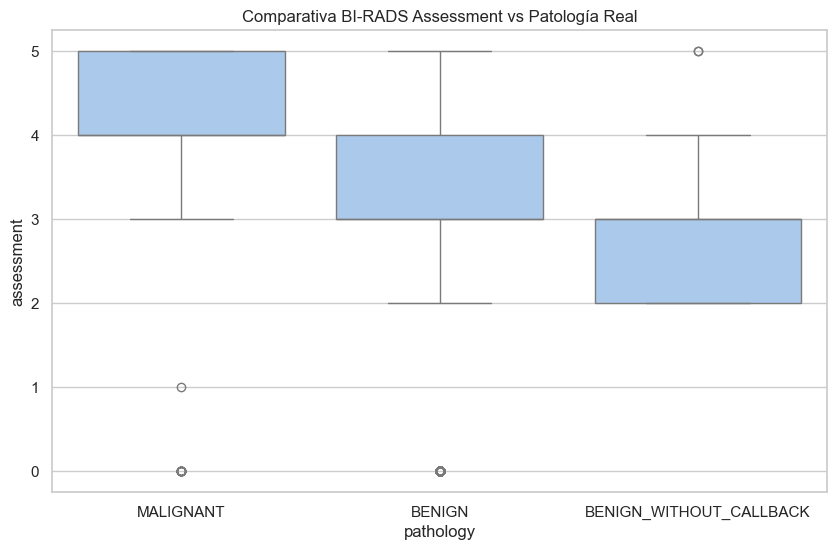

In [8]:
if 'assessment' in df.columns:
    sns.boxplot(data=df, x='pathology', y='assessment')
    plt.title('Comparativa BI-RADS Assessment vs Patología Real')
    plt.show()

## 3. Análisis de Desbalance de Clases
Es crucial entender si hay un sesgo hacia una clase, tanto a nivel de imágenes totales como a nivel de pacientes únicos.

--- Desbalance a nivel de IMAGEN (Global) ---


,Conteo,Porcentaje (%)
pathology,,
MALIGNANT,637,48.330804
BENIGN,577,43.778452
BENIGN_WITHOUT_CALLBACK,104,7.890744



--- Desbalance a nivel de PACIENTE ---


,Conteo,Porcentaje (%)
pathology,,
MALIGNANT,336,48.625181
BENIGN,301,43.560058
BENIGN_WITHOUT_CALLBACK,54,7.814761


/var/folders/n9/rzbr2qw904q1hzjdqbsd0p900000gn/T/ipykernel_69198/2157208234.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=img_stats.index, y='Conteo', data=img_stats.reset_index(), ax=axes[0], palette='viridis')
/var/folders/n9/rzbr2qw904q1hzjdqbsd0p900000gn/T/ipykernel_69198/2157208234.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pat_stats.index, y='Conteo', data=pat_stats.reset_index(), ax=axes[1], palette='magma')


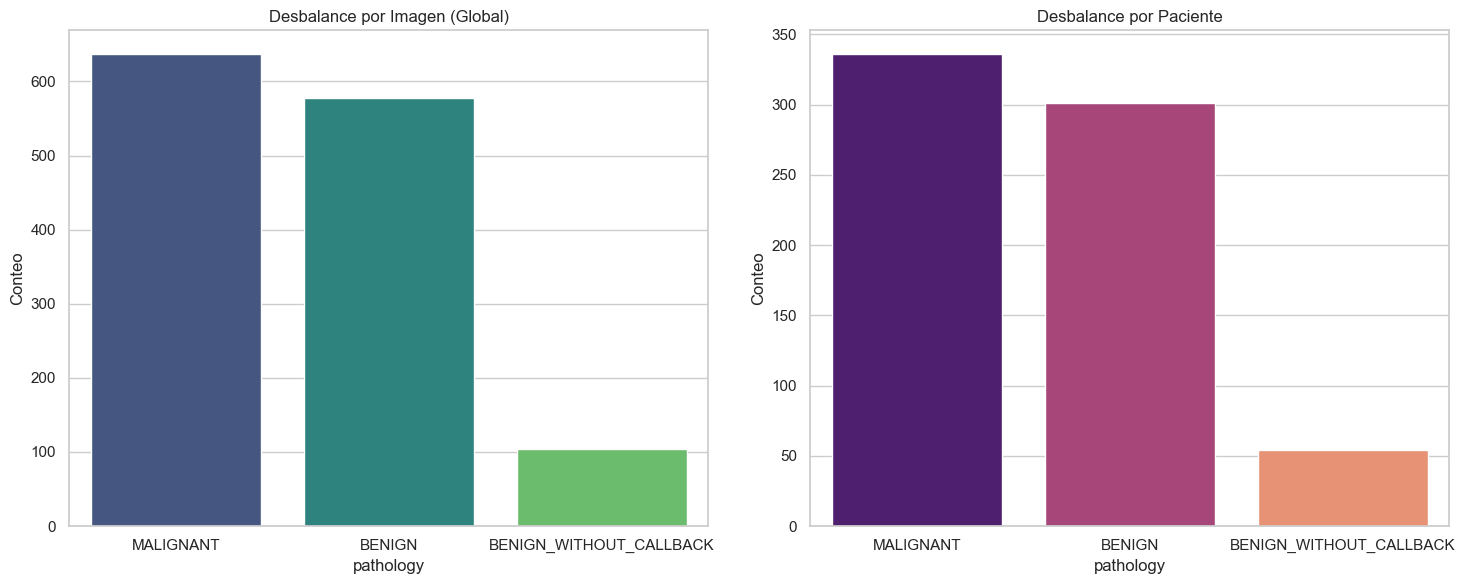

In [9]:
# Desbalance a nivel de IMAGEN
print("--- Desbalance a nivel de IMAGEN (Global) ---")
img_counts = df['pathology'].value_counts()
img_pct = df['pathology'].value_counts(normalize=True) * 100
img_stats = pd.concat([img_counts, img_pct], axis=1)
img_stats.columns = ['Conteo', 'Porcentaje (%)']
display(img_stats)

# Desbalance a nivel de PACIENTE
print("\n--- Desbalance a nivel de PACIENTE ---")
patient_df = get_patient_summary(df)
pat_counts = patient_df['pathology'].value_counts()
pat_pct = patient_df['pathology'].value_counts(normalize=True) * 100
pat_stats = pd.concat([pat_counts, pat_pct], axis=1)
pat_stats.columns = ['Conteo', 'Porcentaje (%)']
display(pat_stats)

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x=img_stats.index, y='Conteo', data=img_stats.reset_index(), ax=axes[0], palette='viridis')
axes[0].set_title('Desbalance por Imagen (Global)')

sns.barplot(x=pat_stats.index, y='Conteo', data=pat_stats.reset_index(), ax=axes[1], palette='magma')
axes[1].set_title('Desbalance por Paciente')

plt.tight_layout()
plt.show()

## 4. Análisis Morfológico (Forma y Márgenes de la Masa)
La literatura médica indica que ciertas formas (como 'Irregular') y márgenes (como 'Spiculated') están altamente correlacionados con malignidad. Vamos a validarlo en este dataset.

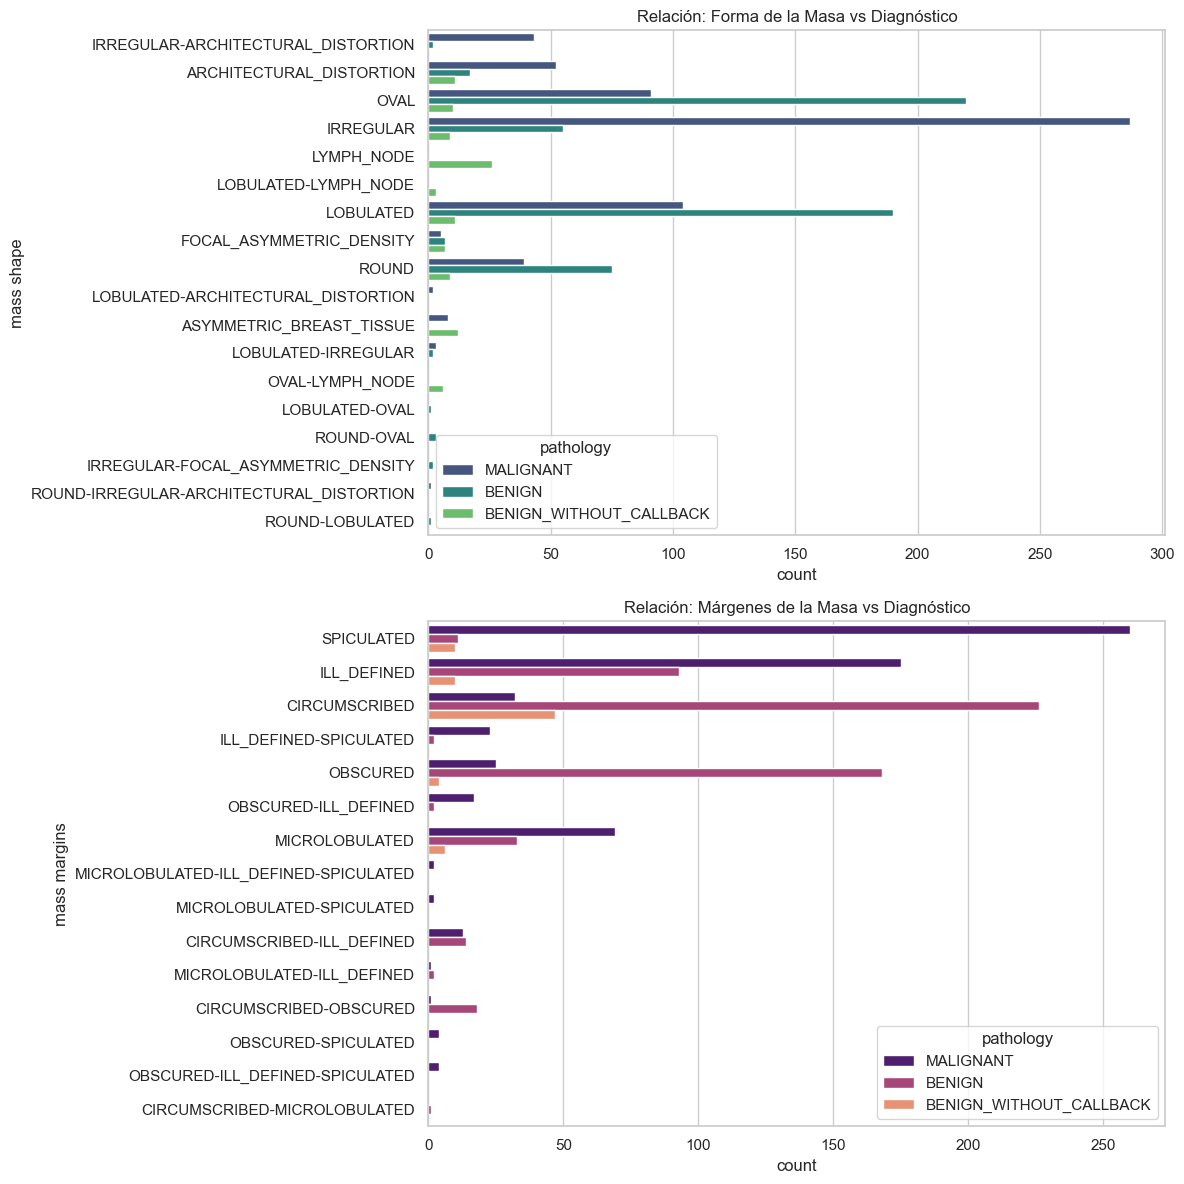

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# Mass Shape vs Pathology
sns.countplot(data=df, y='mass shape', hue='pathology', ax=axes[0], palette='viridis')
axes[0].set_title('Relación: Forma de la Masa vs Diagnóstico')

# Mass Margins vs Pathology
sns.countplot(data=df, y='mass margins', hue='pathology', ax=axes[1], palette='magma')
axes[1].set_title('Relación: Márgenes de la Masa vs Diagnóstico')

plt.tight_layout()
plt.show()

## 5. Densidad Mamaria y Sutileza
La densidad mamaria puede dificultar la detección (tejido blanco oculta cáncer blanco).
La sutileza indica qué tan obvia es la lesión para el radiólogo.

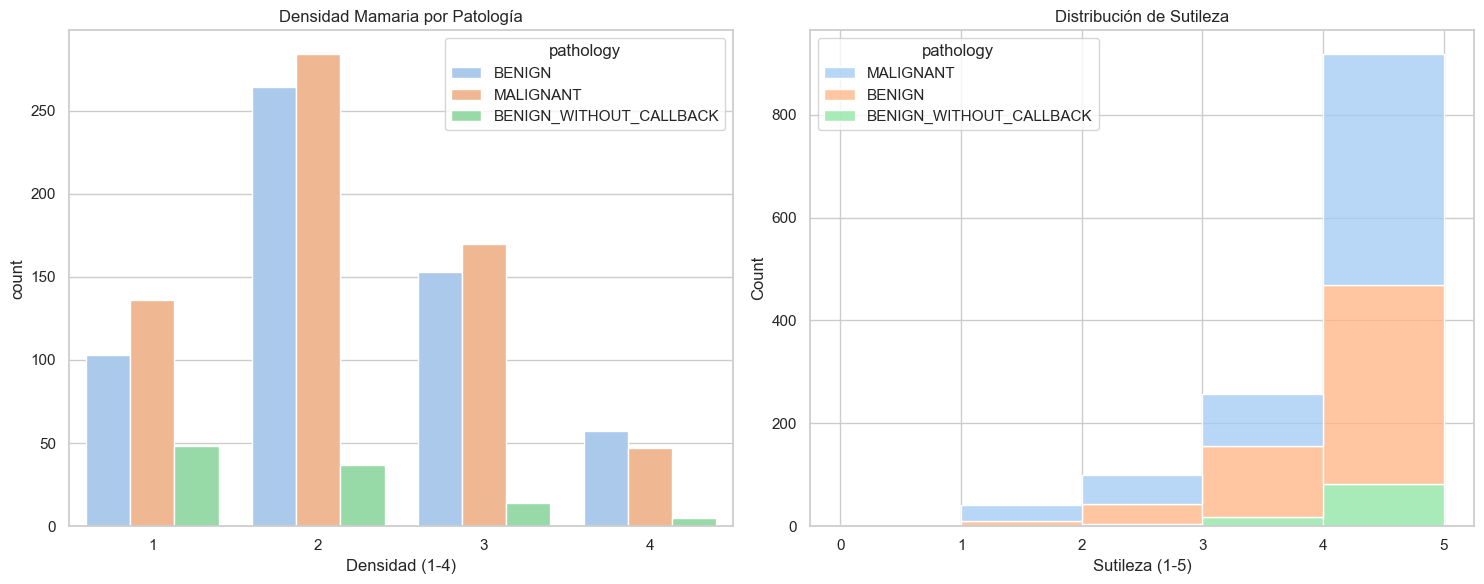

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Breast Density vs Pathology
sns.countplot(data=df, x='breast_density', hue='pathology', ax=axes[0])
axes[0].set_title('Densidad Mamaria por Patología')
axes[0].set_xlabel('Densidad (1-4)')

# Subtlety distribution
sns.histplot(data=df, x='subtlety', hue='pathology', multiple='stack', ax=axes[1], bins=5)
axes[1].set_title('Distribución de Sutileza')
axes[1].set_xlabel('Sutileza (1-5)')

plt.tight_layout()
plt.show()

## 6. Consistencia de Vistas (CC vs MLO)
Lo ideal en clínica es tener ambas proyecciones para cada paciente.

In [12]:
view_counts = df.groupby(['patient_id', 'image view']).size().unstack(fill_value=0)
print("Primeros 10 pacientes y sus vistas disponibles:")
display(view_counts.head(10))

print("\nResumen global de Vistas:")
display(df['image view'].value_counts())

Primeros 10 pacientes y sus vistas disponibles:


image view,CC,MLO
patient_id,,
P_00001,1,1
P_00004,1,2
P_00009,1,1
P_00015,0,1
P_00018,1,1
P_00021,2,2
P_00023,1,1
P_00026,1,1
P_00027,1,1



Resumen global de Vistas:


image view
MLO    711
CC     607
Name: count, dtype: int64

## 7. Matriz de Correlación Categórica
Convertiremos las etiquetas a números para ver qué variables están más conectadas.

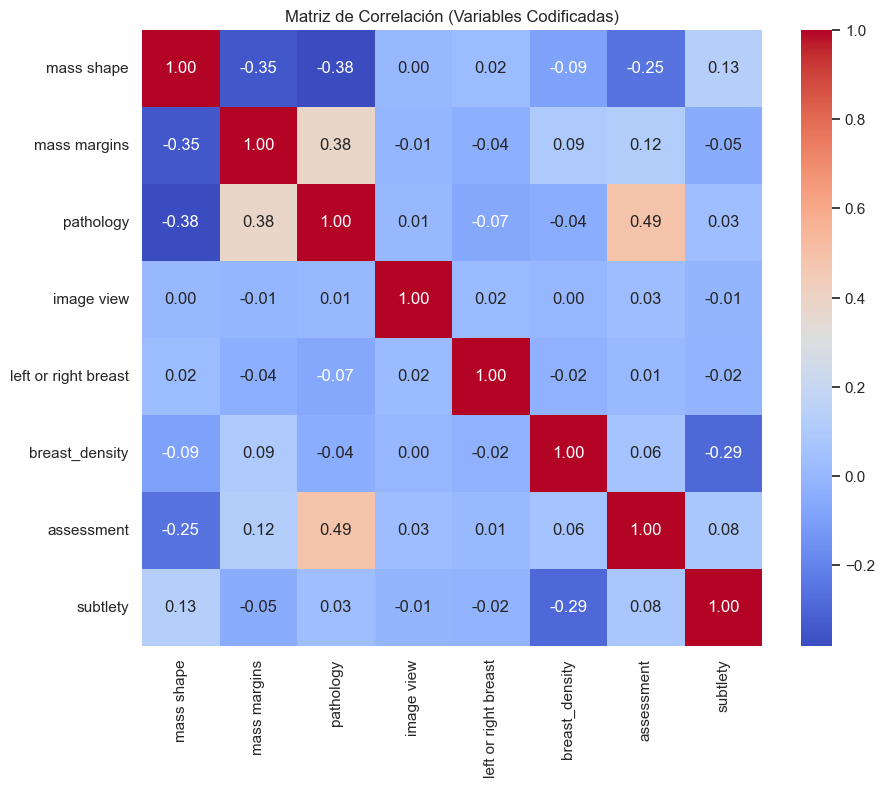

In [13]:
from sklearn.preprocessing import LabelEncoder

cols_to_encode = ['mass shape', 'mass margins', 'pathology', 'image view', 'left or right breast']
df_encoded = df.copy()
le = LabelEncoder()

for col in cols_to_encode:
    # Manejar nulos antes de encodear para evitar errores
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

corr = df_encoded[cols_to_encode + ['breast_density', 'assessment', 'subtlety']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación (Variables Codificadas)')
plt.show()